# 🌸 Excel → PowerPoint, the Gentle Tour 🌸

Hi! 👋 This notebook is a slow, friendly walk through everything that `generate_slides.py` does.

We will build it up the same way you'd build a Lego set: **one piece at a time**.

You can run each cell with **Shift + Enter**.

> 💡 Every cell has a tiny job. If a cell is confusing, that's normal — read it, run it, look at the picture it makes, then move on.

---

## 🗺️ The Big Picture

```
┌───────────────┐        ┌────────────┐         ┌──────────────────┐
│   data.xlsx   │  ───►  │   Python   │   ───►  │   output.pptx    │
│  (the data)   │        │ (the chef) │         │ (the slide deck) │
└───────────────┘        └────────────┘         └──────────────────┘
        ▲                       ▲
        │                       │
   one tab per             template.pptx
   person/topic            (the recipe card —
                          one slide layout we
                           re-use over and over)
```

We'll learn it in **7 small steps**:

1. 📦 What does each `import` actually do?
2. 📗 How do we open and read an Excel file?
3. 🎞️ How do we open a PowerPoint and find what's inside it?
4. ✏️ How do we put **one** piece of info into the slide?
5. 🔁 How do we put **all rows** of one sheet onto a slide?
6. 🧬 How do we make **one slide per sheet** (cloning the template)?
7. 🚀 What does the real `generate_slides.py` add on top of this?

> 🐣 Tip: it's totally OK to run a cell, take a sip of tea, and come back. Progress doesn't have to be fast.

## 🧰 Step 0 — Make sure the kitchen is ready

Before we start cooking, let's make sure the ingredients are on the counter:
- `data.xlsx` (the data)
- `template.pptx` (the slide design)

The cell below just checks the files exist and shows you the project layout.


In [1]:
from pathlib import Path

EXCEL_FILE    = "data.xlsx"
TEMPLATE_FILE = "template.pptx"

print("📁 Project files I can see in this folder:")
for p in sorted(Path(".").iterdir()):
    if p.name.startswith("."):
        continue
    icon = "📂" if p.is_dir() else "📄"
    print(f"   {icon} {p.name}")

print()
for f in [EXCEL_FILE, TEMPLATE_FILE]:
    exists = "✅" if Path(f).exists() else "❌"
    print(f"{exists}  {f}")


📁 Project files I can see in this folder:
   📄 README.md
   📄 data.xlsx
   📄 generate_slides.py
   📄 learn_step_by_step.ipynb
   📂 output
   📄 output.pptx
   📄 output_step1.pptx
   📄 output_step2.pptx
   📄 output_step3.pptx
   📄 requirements.txt
   📄 template.pptx
   📂 venv

✅  data.xlsx
✅  template.pptx


## 📦 Step 1 — Imports (a.k.a. "borrow the right tools")

Python comes with **some** built-in tools, but reading Excel and writing PowerPoint are specialty jobs.
So we **borrow** libraries that someone else already wrote.

Think of imports like reaching into a toolbox 🧰:

| Import | What it gives us | Real-world analogy |
| --- | --- | --- |
| `from pathlib import Path` | a friendly way to talk about files and folders | a label maker for files 🏷️ |
| `import openpyxl` | open and read `.xlsx` Excel files | a magnifying glass for spreadsheets 🔍 |
| `from pptx import Presentation` | open, change, and save `.pptx` files | a paintbrush for slides 🎨 |
| `import copy` | make a perfect duplicate of something | a photocopier 📠 |
| `from lxml import etree` | edit the deep XML guts of a `.pptx` file | a tiny screwdriver 🔩 |

> 🐥 You don't need to memorize these names. Just know: **"if I see these at the top, that's the toolbox."**

Run the next cell. If it prints "all tools loaded" with no errors, your toolbox is good. ✅

In [2]:
import copy
from pathlib import Path

import openpyxl
from lxml import etree
from pptx import Presentation

import matplotlib.pyplot as plt
import matplotlib.patches as patches

print("✅ all tools loaded — your toolbox is ready!")


✅ all tools loaded — your toolbox is ready!


## 📗 Step 2 — Reading the Excel file

An Excel file looks simple from the outside, but inside it's a little family tree:

```
📘 Workbook  (the whole file: data.xlsx)
  └── 📑 Sheet  (a tab at the bottom: "John", "Bob", "Alice"…)
        └── 🟦 Row   (one horizontal line)
              └── ▫ Cell  (one little box with one value)
```

Knowing this tree is HUGE — every line of Excel-reading code is just walking down this tree.

We'll do it in 4 baby steps:
1. Open the workbook.
2. List the sheets.
3. Pick one sheet and read its column headers (row 1).
4. Read the data rows below.

### 2.1 Open the workbook 📘

`openpyxl.load_workbook(...)` is like double-clicking the Excel file — it opens it in memory so Python can poke around.

In [3]:
wb = openpyxl.load_workbook(EXCEL_FILE)

print("📘 Workbook is open!")
print("   Type of `wb`:", type(wb).__name__)
print("   Number of sheets:", len(wb.sheetnames))


📘 Workbook is open!
   Type of `wb`: Workbook
   Number of sheets: 3


### 2.2 List the sheets 📑

`wb.sheetnames` is a list of the tab names you'd see at the bottom of Excel.

The cell below also draws a little picture of the tabs so you can see what we're talking about. 👀

Sheets in this workbook: ['John', 'Bob', 'Alice']


/Users/jrmistry/Documents/github/excel-powerpoint-demo/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128216 (\N{BLUE BOOK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


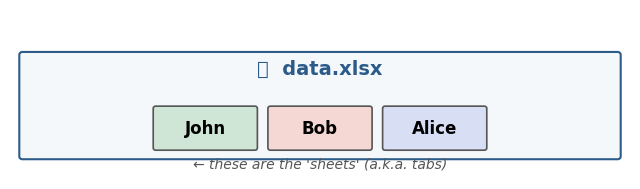

In [4]:
sheet_names = wb.sheetnames
print("Sheets in this workbook:", sheet_names)

fig, ax = plt.subplots(figsize=(8, 2.2))
ax.set_xlim(0, 10)
ax.set_ylim(0, 3)
ax.axis("off")

ax.add_patch(patches.FancyBboxPatch((0.2, 0.4), 9.6, 1.8,
    boxstyle="round,pad=0.05", linewidth=1.5,
    edgecolor="#2c5b8a", facecolor="#f4f8fb"))
ax.text(5, 1.85, "📘  data.xlsx", ha="center", fontsize=14, fontweight="bold", color="#2c5b8a")

colors = ["#cfe5d6", "#f5d7d4", "#d8dff5", "#fbe7c7", "#e7d4f5"]
tab_w = 1.6
gap   = 0.25
total = len(sheet_names) * tab_w + (len(sheet_names) - 1) * gap
start = 5 - total / 2
for i, name in enumerate(sheet_names):
    x = start + i * (tab_w + gap)
    ax.add_patch(patches.FancyBboxPatch((x, 0.55), tab_w, 0.7,
        boxstyle="round,pad=0.04", linewidth=1.2,
        edgecolor="#555", facecolor=colors[i % len(colors)]))
    ax.text(x + tab_w/2, 0.9, name, ha="center", va="center", fontsize=12, fontweight="bold")

ax.text(5, 0.2, "← these are the 'sheets' (a.k.a. tabs)", ha="center", fontsize=10, style="italic", color="#555")
plt.show()


### 2.3 Pick one sheet and read its headers 🟦

To get a single sheet, we use `wb["sheet_name"]` — like opening a file folder by name.

The **headers** are the words in row 1 (`Goal`, `Metric`, …). Everything below row 1 is data.

```
            ┌──────┬────────┐
   row 1 →  │ Goal │ Metric │   ← headers (row 1)
            ├──────┼────────┤
   row 2 →  │  A   │   1    │   ← data
   row 3 →  │  B   │   2    │   ← data
            └──────┴────────┘
```

In [5]:
ws = wb["Bob"]
print(f"📑 Picked the sheet named: {ws.title}")

headers = []
for cell in ws[1]:
    if cell.value is None:
        break
    headers.append(str(cell.value).strip())

print("Headers found in row 1:", headers)


📑 Picked the sheet named: Bob
Headers found in row 1: ['Goal', 'Metric']


### 2.4 Read the data rows 🧾

`ws.iter_rows(min_row=2, values_only=True)` means:
- `min_row=2` → start at row 2 (skip the header row)
- `values_only=True` → just give me the values, not the cell objects

For each row we make a tiny dictionary `{"Goal": "A", "Metric": 1}` so the data is easy to look up by column name later.

In [6]:
data_rows = []
for row in ws.iter_rows(min_row=2, values_only=True):
    if all(v is None for v in row):
        continue
    row_dict = {headers[c]: row[c] for c in range(len(headers))}
    data_rows.append(row_dict)

print(f"Read {len(data_rows)} data row(s) from sheet '{ws.title}':\n")
for i, r in enumerate(data_rows, start=1):
    print(f"  row {i}: {r}")


Read 4 data row(s) from sheet 'Bob':

  row 1: {'Goal': 'A', 'Metric': 1}
  row 2: {'Goal': 'B', 'Metric': 2}
  row 3: {'Goal': 'B', 'Metric': 2.5}
  row 4: {'Goal': 'C', 'Metric': 3}


### 2.5 Draw it like a real spreadsheet 🎨

Sometimes a print-out doesn't *feel* like a spreadsheet. Let's draw the sheet so it looks like Excel:

/Users/jrmistry/Documents/github/excel-powerpoint-demo/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128209 (\N{BOOKMARK TABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


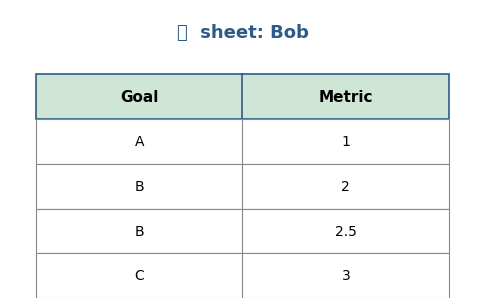

In [7]:
def draw_sheet(headers, data_rows, title="sheet"):
    n_cols = len(headers)
    n_rows = len(data_rows) + 1
    cell_w, cell_h = 2.4, 0.55
    fig_w = max(6, n_cols * cell_w + 1)
    fig_h = max(2.0, n_rows * cell_h + 1)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.set_xlim(0, n_cols * cell_w + 0.6)
    ax.set_ylim(0, n_rows * cell_h + 0.8)
    ax.axis("off")

    ax.text((n_cols * cell_w + 0.6) / 2, n_rows * cell_h + 0.45,
            f"📑  sheet: {title}", ha="center", fontsize=13, fontweight="bold", color="#2c5b8a")

    for c, h in enumerate(headers):
        x = 0.3 + c * cell_w
        y = (n_rows - 1) * cell_h
        ax.add_patch(patches.Rectangle((x, y), cell_w, cell_h,
            edgecolor="#2c5b8a", facecolor="#cfe5d6", linewidth=1.2))
        ax.text(x + cell_w/2, y + cell_h/2, str(h), ha="center", va="center",
                fontsize=11, fontweight="bold")

    for r, row in enumerate(data_rows):
        for c, h in enumerate(headers):
            x = 0.3 + c * cell_w
            y = (n_rows - 2 - r) * cell_h
            val = row.get(h)
            txt = "" if val is None else str(val)
            if len(txt) > 30:
                txt = txt[:27] + "…"
            ax.add_patch(patches.Rectangle((x, y), cell_w, cell_h,
                edgecolor="#888", facecolor="white", linewidth=0.8))
            ax.text(x + cell_w/2, y + cell_h/2, txt, ha="center", va="center", fontsize=10)
    plt.show()

draw_sheet(headers, data_rows, title=ws.title)


## 🎞️ Step 3 — Opening the PowerPoint template

A PowerPoint file has a similar family tree:

```
🎞️ Presentation  (the whole .pptx file)
  └── 🖼️ Slide   (one page)
        └── 🟦 Shape  (a title box, a picture, a table, …)
              └── 🟫 Cell  (only inside table shapes)
```

So when we want to put text "into PowerPoint", we are really:
1. Opening the presentation
2. Picking a slide
3. Finding the right shape on that slide
4. (If it's a table) finding the right cell in that table

Let's open `template.pptx` and **list everything inside the first slide**.

In [8]:
prs = Presentation(TEMPLATE_FILE)

print(f"🎞️  template.pptx opened — it has {len(prs.slides)} slide(s).\n")

slide = prs.slides[0]
print("Shapes on slide 1:")
for s in slide.shapes:
    kind = "TABLE" if s.has_table else ("TEXT BOX" if s.has_text_frame else str(s.shape_type))
    sample = ""
    if s.has_text_frame and s.text_frame.text.strip():
        sample = f"  text={s.text_frame.text!r}"
    print(f"  • name={s.name!r:15} kind={kind}{sample}")


🎞️  template.pptx opened — it has 1 slide(s).

Shapes on slide 1:
  • name='Title 1'       kind=TEXT BOX  text='{{name}}'
  • name='Table 2'       kind=TABLE


### 3.1 Draw the slide so you can see where the shapes live 🗺️

PowerPoint measures everything in **EMU** (English Metric Units) — a tiny unit. Don't worry about the math; we just use the numbers `python-pptx` gives us.

The cell below draws the slide as a rectangle and overlays each shape in its real position:

/Users/jrmistry/Documents/github/excel-powerpoint-demo/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


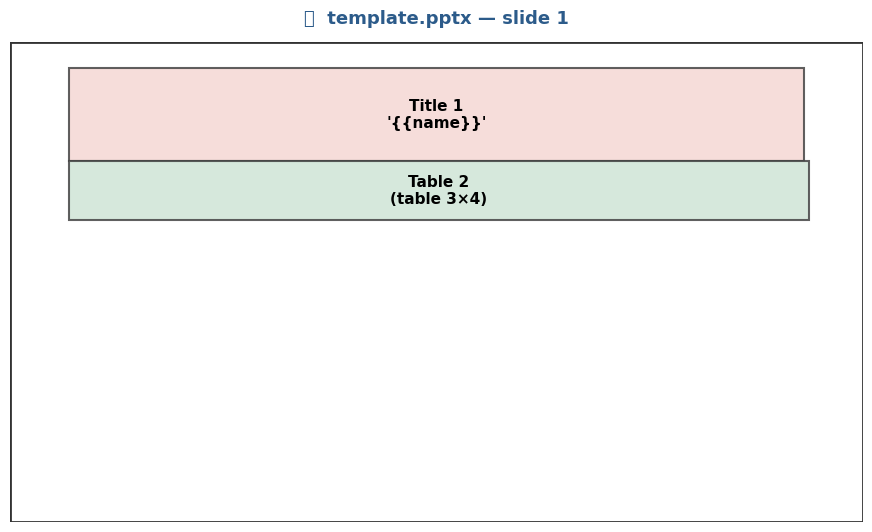

In [9]:
def draw_slide(slide, slide_w, slide_h, title="slide"):
    fig, ax = plt.subplots(figsize=(11, 6.4))
    ax.set_xlim(0, slide_w)
    ax.set_ylim(slide_h, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.add_patch(patches.Rectangle((0, 0), slide_w, slide_h,
        edgecolor="#333", facecolor="white", linewidth=2))
    ax.text(slide_w/2, -slide_h*0.04, f"🖼️  {title}",
            ha="center", fontsize=13, fontweight="bold", color="#2c5b8a")

    palette = ["#f5d7d4", "#cfe5d6", "#d8dff5", "#fbe7c7", "#e7d4f5"]
    for i, s in enumerate(slide.shapes):
        color = palette[i % len(palette)]
        ax.add_patch(patches.Rectangle((s.left, s.top), s.width, s.height,
            edgecolor="#444", facecolor=color, linewidth=1.5, alpha=0.85))
        label = s.name
        if s.has_table:
            label += f"\n(table {len(s.table.rows)}×{len(s.table.columns)})"
        elif s.has_text_frame and s.text_frame.text.strip():
            label += f"\n{s.text_frame.text!r}"
        ax.text(s.left + s.width/2, s.top + s.height/2, label,
                ha="center", va="center", fontsize=11, fontweight="bold")
    plt.show()

draw_slide(slide, prs.slide_width, prs.slide_height, title="template.pptx — slide 1")


### 3.2 Find the title and the table 🎯

We don't want to hard-code "shape number 1 is the title". We want to **search**:
- "Give me the shape that has text in it" → that's our **title**.
- "Give me the shape that is a table" → that's where data goes.

This way, even if the template gets re-arranged, our code still works. 🪄

In [10]:
def find_table(slide):
    for shape in slide.shapes:
        if shape.has_table:
            return shape
    return None

table_shape = find_table(slide)
table = table_shape.table

print(f"🟦 Found a table: {table_shape.name}")
print(f"   It has {len(table.rows)} rows and {len(table.columns)} columns.\n")

print("Cell-by-cell view of the template's table:")
for r_i, row in enumerate(table.rows):
    cells_txt = [c.text_frame.text or "·" for c in row.cells]
    print(f"   row {r_i}: {cells_txt}")


🟦 Found a table: Table 2
   It has 3 rows and 4 columns.

Cell-by-cell view of the template's table:
   row 0: ['Goal', 'Goal2', 'Metric', 'Metric2']
   row 1: ['x', '·', '·', '·']
   row 2: ['·', '·', '·', '·']


> 🪞 Notice that the table's **row 0** is the header (`Goal`, `Goal2`, `Metric`, `Metric2`) — exactly the same idea as Excel row 1. PowerPoint and Excel both put column names at the top.

## ✏️ Step 4 — Put ONE piece of info into the slide

Time to actually change something! We'll do **two tiny edits**:

1. Replace the title text `{{name}}` with the sheet name.
2. Type one piece of data into one cell of the table.

Then we save and you can open the file in PowerPoint to see the change. 🎉

---

### 4.1 Replace the title placeholder `{{name}}`

In the template, the title literally says `{{name}}`. That's a **placeholder** — a marker meaning "swap me out later".
We loop through every text run on the slide and do a `string.replace("{{name}}", "Bob")`.

Why so much code for a `replace`? Because PowerPoint can split text into pieces called **runs** (think: bold here, italic there). We have to look inside each run individually.

In [11]:
def replace_placeholder(slide, placeholder, value):
    for shape in slide.shapes:
        if not shape.has_text_frame:
            continue
        for para in shape.text_frame.paragraphs:
            for run in para.runs:
                if placeholder in run.text:
                    run.text = run.text.replace(placeholder, value)

replace_placeholder(slide, "{{name}}", "Bob")

print("Title text after the replace:")
for shape in slide.shapes:
    if shape.has_text_frame and shape.text_frame.text.strip():
        print(" ", repr(shape.text_frame.text))


Title text after the replace:
  'Bob'


### 4.2 The big idea: matching columns by name 🤝

Here's the trick the whole project depends on. We don't say "Excel column 0 goes to PowerPoint column 0".

Instead we say: **"the columns whose NAMES match are the same column."**

```
   Excel headers          PowerPoint table headers
   ─────────────         ─────────────────────────
     Goal      ─────────────►  Goal
     Metric    ─────────────►  Metric
                                Goal2     ← (no Excel column → leave empty)
                                Metric2   ← (no Excel column → leave empty)
```

This means you can rearrange the columns in either file and the code keeps working. 💛

Let's build that mapping for the "Bob" sheet and visualize it:

In [12]:
pptx_headers = [c.text_frame.text.strip() for c in table.rows[0].cells]
print("PowerPoint table headers:", pptx_headers)
print("Excel sheet headers:     ", headers)

col_map = {pptx_idx: name for pptx_idx, name in enumerate(pptx_headers) if name in headers}
print("\ncol_map (PowerPoint column index → Excel column name):")
for k, v in col_map.items():
    print(f"   pptx col {k}  ↔  Excel column {v!r}")


PowerPoint table headers: ['Goal', 'Goal2', 'Metric', 'Metric2']
Excel sheet headers:      ['Goal', 'Metric']

col_map (PowerPoint column index → Excel column name):
   pptx col 0  ↔  Excel column 'Goal'
   pptx col 2  ↔  Excel column 'Metric'


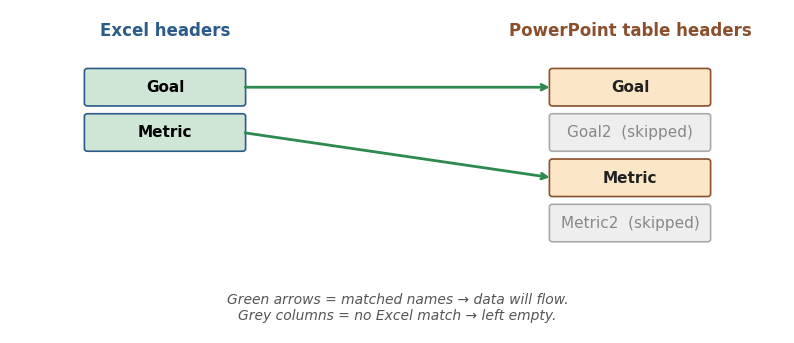

In [13]:
def draw_column_mapping(excel_headers, pptx_headers, col_map):
    fig, ax = plt.subplots(figsize=(10, 4.2))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 5)
    ax.axis("off")

    ax.text(2.0, 4.6, "Excel headers", ha="center", fontsize=12, fontweight="bold", color="#2c5b8a")
    ax.text(8.0, 4.6, "PowerPoint table headers", ha="center", fontsize=12, fontweight="bold", color="#8a4f2c")

    excel_y = {}
    for i, h in enumerate(excel_headers):
        y = 3.8 - i * 0.7
        excel_y[h] = y
        ax.add_patch(patches.FancyBboxPatch((1.0, y - 0.25), 2.0, 0.5,
            boxstyle="round,pad=0.04", facecolor="#cfe5d6", edgecolor="#2c5b8a", linewidth=1.2))
        ax.text(2.0, y, h, ha="center", va="center", fontsize=11, fontweight="bold")

    pptx_y = {}
    for i, h in enumerate(pptx_headers):
        y = 3.8 - i * 0.7
        pptx_y[i] = y
        in_map = i in col_map
        face = "#fbe7c7" if in_map else "#eeeeee"
        ax.add_patch(patches.FancyBboxPatch((7.0, y - 0.25), 2.0, 0.5,
            boxstyle="round,pad=0.04", facecolor=face,
            edgecolor="#8a4f2c" if in_map else "#aaa", linewidth=1.2))
        suffix = "" if in_map else "  (skipped)"
        ax.text(8.0, y, h + suffix, ha="center", va="center", fontsize=11,
                fontweight="bold" if in_map else "normal",
                color="#222" if in_map else "#888")

    for pptx_idx, ex_name in col_map.items():
        y_left  = excel_y[ex_name]
        y_right = pptx_y[pptx_idx]
        ax.annotate("", xy=(7.0, y_right), xytext=(3.0, y_left),
                    arrowprops=dict(arrowstyle="->", color="#2c8a4f", lw=2))

    ax.text(5.0, 0.2,
            "Green arrows = matched names → data will flow.\nGrey columns = no Excel match → left empty.",
            ha="center", fontsize=10, style="italic", color="#555")
    plt.show()

draw_column_mapping(headers, pptx_headers, col_map)


### 4.3 Type ONE row of data into the table ✍️

The template's table already has 2 placeholder rows under the header. Let's just type into the **first** placeholder row.

For each column in the table:
- If `col_map` says it matches an Excel column, write that value.
- Otherwise leave it blank.

We use the simple, beginner-friendly API: `table.cell(row, col).text = "..."`

In [14]:
first_row = data_rows[0]
print("The first Excel row we'll insert:", first_row)
print()

for pptx_col_idx in range(len(table.columns)):
    excel_col_name = col_map.get(pptx_col_idx)
    if excel_col_name is None:
        value = ""
    else:
        value = first_row.get(excel_col_name)
    cell = table.cell(1, pptx_col_idx)
    cell.text = "" if value is None else str(value)
    print(f"   wrote into pptx row 1, col {pptx_col_idx}  →  {cell.text!r}")

prs.save("output_step1.pptx")
print("\n💾 saved output_step1.pptx — open it in PowerPoint to see your first edit!")


The first Excel row we'll insert: {'Goal': 'A', 'Metric': 1}

   wrote into pptx row 1, col 0  →  'A'
   wrote into pptx row 1, col 1  →  ''
   wrote into pptx row 1, col 2  →  '1'
   wrote into pptx row 1, col 3  →  ''

💾 saved output_step1.pptx — open it in PowerPoint to see your first edit!


## 🔁 Step 5 — Put **all** rows of one sheet into the slide

The template only had 2 empty rows. But sheets can have lots more!
So we need to **add new rows** to the table.

😵 Tiny gotcha: `python-pptx` doesn't have a friendly `table.add_row()`. So we have to drop down one level and write a tiny piece of XML — the deep file format inside a `.pptx`.

Don't panic! The function below is just a polite way to say:
> "Make a new row. For each column, drop in the right text. Stick it on the bottom of the table."

Read it slowly. Then run it.

In [15]:
NS = "http://schemas.openxmlformats.org/drawingml/2006/main"

def add_simple_row(table, col_map, row_data, font_size_pt=11):
    """Append one new row to a python-pptx `table`, filling cells from col_map."""
    tbl       = table._tbl
    header_tr = tbl.findall(f"{{{NS}}}tr")[0]
    num_cols  = len(header_tr.findall(f"{{{NS}}}tc"))

    new_tr = etree.SubElement(tbl, f"{{{NS}}}tr")
    new_tr.set("h", "0")

    for col_idx in range(num_cols):
        col_name = col_map.get(col_idx)
        value    = "" if col_name is None else row_data.get(col_name)
        text     = "" if value is None else str(value)

        tc     = etree.SubElement(new_tr, f"{{{NS}}}tc")
        txBody = etree.SubElement(tc, f"{{{NS}}}txBody")
        etree.SubElement(txBody, f"{{{NS}}}bodyPr")
        etree.SubElement(txBody, f"{{{NS}}}lstStyle")
        p      = etree.SubElement(txBody, f"{{{NS}}}p")
        if text:
            r   = etree.SubElement(p, f"{{{NS}}}r")
            rPr = etree.SubElement(r, f"{{{NS}}}rPr")
            rPr.set("lang", "en-US")
            rPr.set("sz", str(font_size_pt * 100))
            t = etree.SubElement(r, f"{{{NS}}}t")
            t.text = text
        etree.SubElement(tc, f"{{{NS}}}tcPr")

print("✅ helper add_simple_row() is ready to use")


✅ helper add_simple_row() is ready to use


### 5.1 Loop the rows 🔁

Now we get a fresh template, replace the title, **clear** the placeholder data rows, then loop through every Excel row and add it.

The loop is the same idea as a recipe:
> "For each item in the list, do the same little thing."

In [16]:
prs = Presentation(TEMPLATE_FILE)
slide = prs.slides[0]

replace_placeholder(slide, "{{name}}", "Bob")

table = find_table(slide).table
pptx_headers = [c.text_frame.text.strip() for c in table.rows[0].cells]
col_map = {i: name for i, name in enumerate(pptx_headers) if name in headers}

tbl = table._tbl
for tr in tbl.findall(f"{{{NS}}}tr")[1:]:
    tbl.remove(tr)

print(f"Adding {len(data_rows)} rows for sheet 'Bob'...\n")
for i, row in enumerate(data_rows, start=1):
    add_simple_row(table, col_map, row)
    print(f"   row {i} added: {row}")

prs.save("output_step2.pptx")
print("\n💾 saved output_step2.pptx — open it to see ALL the rows of Bob's sheet!")


Adding 4 rows for sheet 'Bob'...

   row 1 added: {'Goal': 'A', 'Metric': 1}
   row 2 added: {'Goal': 'B', 'Metric': 2}
   row 3 added: {'Goal': 'B', 'Metric': 2.5}
   row 4 added: {'Goal': 'C', 'Metric': 3}

💾 saved output_step2.pptx — open it to see ALL the rows of Bob's sheet!


## 🧬 Step 6 — One slide per Excel sheet (cloning the template)

The template only has **one** slide. But our Excel has **three** sheets (`John`, `Bob`, `Alice`).
We want **three** slides in the output — one per sheet, each looking like the template.

The trick is to **clone** the template slide for every sheet after the first.

```
   template.pptx (1 slide)
        │
        ▼
   ┌───────────┐  ┌───────────┐  ┌───────────┐
   │  John     │  │  Bob      │  │  Alice    │
   │  (orig.)  │  │  (clone)  │  │  (clone)  │
   └───────────┘  └───────────┘  └───────────┘
        ↑              ↑              ↑
        └──────────────┴──────────────┘
                cloned slides share
                the same look
```

Cloning is the trickiest piece in the whole project, so we wrap it in a helper:

In [17]:
def clone_slide(prs, original_sp_tree, layout):
    """Add a new slide to `prs` and copy the original template's shapes into it."""
    new_slide = prs.slides.add_slide(layout)
    sp_tree   = new_slide.shapes._spTree

    for child in list(sp_tree)[2:]:
        sp_tree.remove(child)

    for child in list(original_sp_tree)[2:]:
        sp_tree.append(copy.deepcopy(child))

    return new_slide

print("✅ helper clone_slide() is ready")


✅ helper clone_slide() is ready


### 6.1 Now let's wire everything together 🪡

We'll build a baby version of the real `generate_slides.py`:

```
For each sheet in the Excel file:
    1. Read its headers and rows.
    2. Get a slide (use the template's slide for the first sheet, clone it for the rest).
    3. Replace the title placeholder with the sheet name.
    4. Match Excel columns ↔ PowerPoint table columns.
    5. Clear the placeholder rows.
    6. Add one row to the table for each Excel data row.
Save the file.
```

That's it. Everything else in `generate_slides.py` is decoration on top of this loop. ✨

In [18]:
def read_sheet(ws):
    """Return (headers, data_rows) for one Excel worksheet."""
    headers = []
    for cell in ws[1]:
        if cell.value is None:
            break
        headers.append(str(cell.value).strip())

    data_rows = []
    for row in ws.iter_rows(min_row=2, values_only=True):
        if all(v is None for v in row):
            continue
        data_rows.append({headers[c]: row[c] for c in range(min(len(headers), len(row)))})

    return headers, data_rows


wb  = openpyxl.load_workbook(EXCEL_FILE)
prs = Presentation(TEMPLATE_FILE)

template_slide   = prs.slides[0]
original_sp_tree = copy.deepcopy(template_slide.shapes._spTree)
template_layout  = template_slide.slide_layout

first_slide_used = False

for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]
    sheet_headers, sheet_rows = read_sheet(ws)
    print(f"📑 {sheet_name}: {len(sheet_rows)} row(s), columns {sheet_headers}")

    if not first_slide_used:
        slide = template_slide
        first_slide_used = True
    else:
        slide = clone_slide(prs, original_sp_tree, template_layout)

    replace_placeholder(slide, "{{name}}", sheet_name)

    table = find_table(slide).table
    pptx_headers = [c.text_frame.text.strip() for c in table.rows[0].cells]
    col_map = {i: name for i, name in enumerate(pptx_headers) if name in sheet_headers}

    tbl = table._tbl
    for tr in tbl.findall(f"{{{NS}}}tr")[1:]:
        tbl.remove(tr)

    for row in sheet_rows:
        add_simple_row(table, col_map, row)

    print(f"   → slide built with {len(sheet_rows)} data row(s)\n")

prs.save("output_step3.pptx")
print(f"💾 saved output_step3.pptx — it now has {len(prs.slides)} slide(s) (one per sheet).")


📑 John: 14 row(s), columns ['Goal', 'Metric']
   → slide built with 14 data row(s)

📑 Bob: 4 row(s), columns ['Goal', 'Metric']
   → slide built with 4 data row(s)

📑 Alice: 47 row(s), columns ['Goal', 'Goal2', 'Metric', 'Metric2']
   → slide built with 47 data row(s)

💾 saved output_step3.pptx — it now has 3 slide(s) (one per sheet).


### 6.2 Sneak peek of all the slides 👀

Let's draw a tiny picture of every slide we just made — like contact sheets for a roll of film:

/var/folders/f_/2pv960t57v39v447d_nbwj0m0000gn/T/ipykernel_35530/2971322563.py:25: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/jrmistry/Documents/github/excel-powerpoint-demo/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


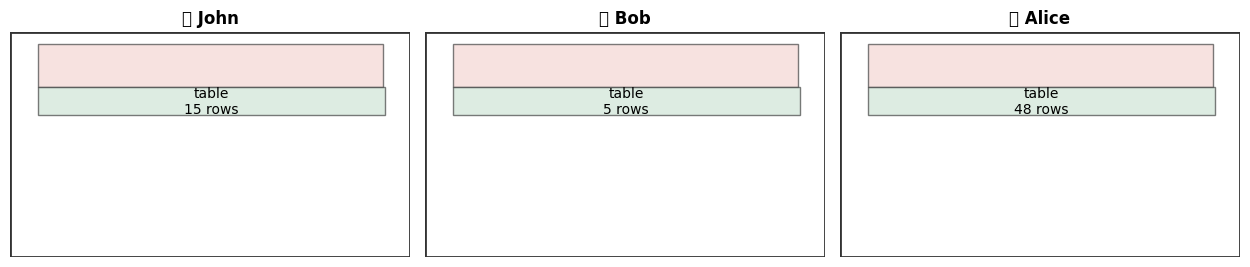

In [19]:
def thumbnails(prs, max_slides=6):
    n = min(len(prs.slides), max_slides)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 3.0))
    if n == 1:
        axes = [axes]
    sw, sh = prs.slide_width, prs.slide_height
    palette = ["#f5d7d4", "#cfe5d6", "#d8dff5", "#fbe7c7", "#e7d4f5"]
    for ax, slide in zip(axes, prs.slides):
        ax.set_xlim(0, sw); ax.set_ylim(sh, 0)
        ax.set_aspect("equal"); ax.axis("off")
        ax.add_patch(patches.Rectangle((0, 0), sw, sh,
            edgecolor="#333", facecolor="white", linewidth=2))
        title_text = "?"
        for i, s in enumerate(slide.shapes):
            color = palette[i % len(palette)]
            ax.add_patch(patches.Rectangle((s.left, s.top), s.width, s.height,
                edgecolor="#444", facecolor=color, linewidth=1, alpha=0.7))
            if s.has_text_frame and s.text_frame.text.strip():
                title_text = s.text_frame.text.strip()
            if s.has_table:
                rows = len(s.table.rows)
                ax.text(s.left + s.width/2, s.top + s.height/2,
                        f"table\n{rows} rows", ha="center", va="center", fontsize=10)
        ax.set_title(f"📄 {title_text}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

thumbnails(prs)


## 🚀 Step 7 — From this notebook to the real `generate_slides.py`

You did it!! 🎉 Everything you ran above is the **core** of the real script.

The real script (`generate_slides.py`) is the same loop with a few extras layered on. Here's a map of those extras so they don't feel scary when you read the file:

| Extra in `generate_slides.py` | What it does | One-line summary |
| --- | --- | --- |
| `EXCLUDE_SHEETS` | Skips sheets like `"Bob"` | "Don't make a slide for this person." |
| `SORT_COLUMNS` | Sorts rows before insert | "Group rows by Goal so they're tidy." |
| `STRIP_WHITESPACE` | Trims spaces from cell text | "Clean up sloppy spaces." |
| `MERGE_COLUMNS` | Merges repeating cells vertically | "If three rows have Goal = 'A', show 'A' once spanning all three." |
| `ALTERNATING_ROW_COLORS` | Light/clear row banding | "Easier to read." |
| `BOLD_COLUMNS` | Make some columns bold | "Goal column should pop." |
| `OVERFLOW_SLIDES` + `estimate_row_height` | If a sheet has too many rows for one slide, spill onto a "(cont.)" slide | "Don't run off the page." |
| `EXPORT_PNGS` | Optional layout previews | "Sanity-check screenshots." |

The cell below runs the real script so you can compare its `output.pptx` to your `output_step3.pptx`.

In [20]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, "generate_slides.py"],
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)
else:
    print("✨ Compare these two files in PowerPoint:")
    print("   • output_step3.pptx   ← built in this notebook")
    print("   • output.pptx         ← built by the real script")


Sheets found: John, Bob, Alice

Sheet 'John': 14 data row(s), columns: ['Goal', 'Metric']
  Matched : ['Goal', 'Metric']
[SKIP] 'Bob': in exclude list.
Sheet 'Alice': 47 data row(s), columns: ['Goal', 'Goal2', 'Metric', 'Metric2']
  Matched : ['Goal', 'Goal2', 'Metric', 'Metric2']

Done — 9 slide(s) created: John, John (cont.), John (cont.), John (cont.), John (cont.), John (cont.), Alice, Alice (cont.), Alice (cont.)
Output saved to: output.pptx

✨ Compare these two files in PowerPoint:
   • output_step3.pptx   ← built in this notebook
   • output.pptx         ← built by the real script


## 🌷 You learned a lot today

Let's recap what you can now do:

1. **Imports** — borrow the right tools from Python's toolbox.
2. **Excel** — open a workbook, list its sheets, read headers, read rows.
3. **PowerPoint** — open a deck, find shapes, find a table inside a slide.
4. **One edit** — replace a placeholder, type into one cell.
5. **Looping rows** — add new rows to a table for every Excel row.
6. **Looping sheets** — clone the template once per sheet to make a multi-slide deck.
7. **The real script** — same pattern, plus polish (sorting, merging, banding, overflow).

> 🐣 If anything still feels fuzzy, the *best* next move is to re-run the cells in just **one** section.
> Watch what changes. That's how the brain stitches it together.

You're doing amazing. 💛